# Agrupando colores

Vamos a crear imagees con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [23]:
# importa las librerías
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpl
from sklearn.cluster import KMeans

#### 2. Lee las imagees
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una image pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [24]:
image = mpl.imread("./ladybug.png")
image.shape

(533, 800, 3)

Muestra la image para ver que se ha cargado bien

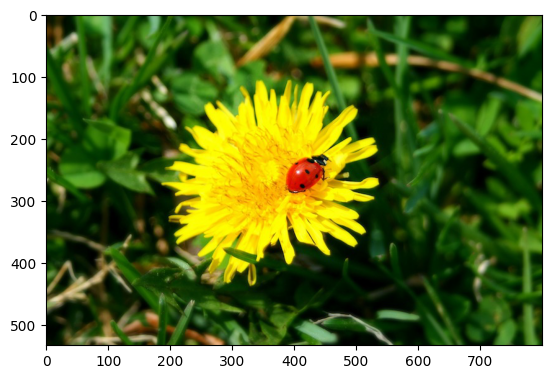

In [25]:
plt.imshow(image)

#### 3. Modifica la estructura de la image
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra image de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [26]:
# modifica las dimensiones del numpy array
n_filas, n_cols, canales = image.shape
image_reshaped = image.reshape(-1, 3)

#### 4. K-means
Haz un k-means con la image de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu image de salida

In [27]:
kmeans = KMeans(n_clusters= 8, random_state=42, max_iter= 10)
image_re = kmeans.fit_predict(image_reshaped)
image_re

array([0, 0, 0, ..., 0, 0, 0], shape=(426400,), dtype=int32)

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizas para crear una nueva image (recuerda que las imagees simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [28]:
clusters = kmeans.cluster_centers_
labels = kmeans.labels_

print(clusters.shape)
print(labels.shape)

image_re = clusters[labels]
image_re

(8, 3)
(426400,)


array([[0.03092706, 0.12990578, 0.00666662],
       [0.03092706, 0.12990578, 0.00666662],
       [0.03092706, 0.12990578, 0.00666662],
       ...,
       [0.03092706, 0.12990578, 0.00666662],
       [0.03092706, 0.12990578, 0.00666662],
       [0.03092706, 0.12990578, 0.00666662]],
      shape=(426400, 3), dtype=float32)

#### 6. Modifica la estructura de la image
Para trabajar con el k-means requeriamos que la image original fuese un solo vector, ahora como queremos volver a tener la image para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la image original te será más facil hacer este paso)

In [29]:
image_re = image_re.reshape(533, 800, 3)

#### 7. Imprime y guarda en tu ordenador la image resultante

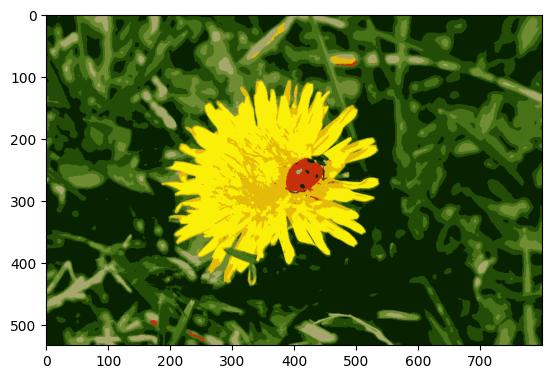

In [30]:
plt.imshow(image_re)

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una image, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [31]:
print(image_re.shape[0])
print(image_re.shape[1])
print(image_re.shape[2])

533
800
3


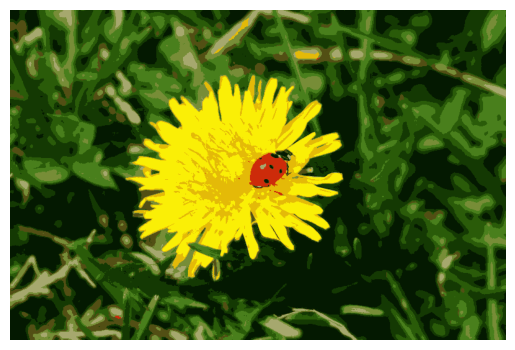

array([[[0.01886362, 0.10037902, 0.00528858],
        [0.01886362, 0.10037902, 0.00528858],
        [0.01886362, 0.10037902, 0.00528858],
        ...,
        [0.165146  , 0.35938174, 0.03781728],
        [0.165146  , 0.35938174, 0.03781728],
        [0.165146  , 0.35938174, 0.03781728]],

       [[0.01886362, 0.10037902, 0.00528858],
        [0.01886362, 0.10037902, 0.00528858],
        [0.01886362, 0.10037902, 0.00528858],
        ...,
        [0.28864625, 0.49884248, 0.11035064],
        [0.28864625, 0.49884248, 0.11035064],
        [0.165146  , 0.35938174, 0.03781728]],

       [[0.01886362, 0.10037902, 0.00528858],
        [0.01886362, 0.10037902, 0.00528858],
        [0.01886362, 0.10037902, 0.00528858],
        ...,
        [0.28864625, 0.49884248, 0.11035064],
        [0.28864625, 0.49884248, 0.11035064],
        [0.165146  , 0.35938174, 0.03781728]],

       ...,

       [[0.01886362, 0.10037902, 0.00528858],
        [0.01886362, 0.10037902, 0.00528858],
        [0.01886362, 0

In [32]:
def image_mod(image, n_colores, guardar=False, nombre="image_mod.png"):
    pixeles = image.reshape(-1, 3)
    
    kmeans = KMeans(n_clusters=n_colores, random_state=42, max_iter=30)
    labels = kmeans.fit_predict(pixeles)
    centroides = kmeans.cluster_centers_
    
    new_pixels = centroides[labels]
    
    new_image = new_pixels.reshape(image.shape[0], image.shape[1], 3)
    
    if guardar:
        plt.imsave(nombre, new_image)
        print(f"✅ image guardada como: {nombre}")
    else:
        plt.imshow(new_image)
        plt.axis('off')
        plt.show()
        
    return new_image


image_mod(image, n_colores=10, guardar=False)

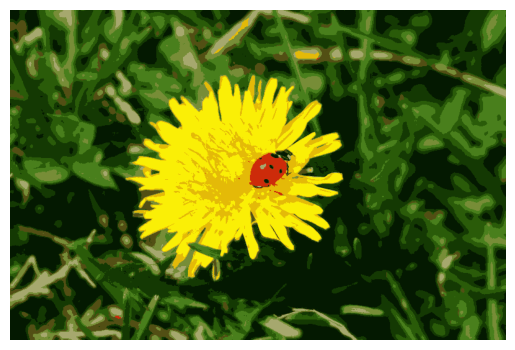

array([[[0.01886362, 0.10037905, 0.00528858],
        [0.01886362, 0.10037905, 0.00528858],
        [0.01886362, 0.10037905, 0.00528858],
        ...,
        [0.165146  , 0.35938174, 0.03781728],
        [0.165146  , 0.35938174, 0.03781728],
        [0.165146  , 0.35938174, 0.03781728]],

       [[0.01886362, 0.10037905, 0.00528858],
        [0.01886362, 0.10037905, 0.00528858],
        [0.01886362, 0.10037905, 0.00528858],
        ...,
        [0.28864625, 0.49884245, 0.11035064],
        [0.28864625, 0.49884245, 0.11035064],
        [0.165146  , 0.35938174, 0.03781728]],

       [[0.01886362, 0.10037905, 0.00528858],
        [0.01886362, 0.10037905, 0.00528858],
        [0.01886362, 0.10037905, 0.00528858],
        ...,
        [0.28864625, 0.49884245, 0.11035064],
        [0.28864625, 0.49884245, 0.11035064],
        [0.165146  , 0.35938174, 0.03781728]],

       ...,

       [[0.01886362, 0.10037905, 0.00528858],
        [0.01886362, 0.10037905, 0.00528858],
        [0.01886362, 0

In [34]:
image_mod(image, 10)